# Survival Analysis — Time-to-Event in Security

Security events have duration. Dwell time, time-to-patch, time-to-detect — these
are all *time-to-event* problems, and they share a statistical structure that
ordinary summary statistics handle poorly. Censoring is natural: some
vulnerabilities are not patched by the end of an observation window, and dropping
them biases every estimate. Means lie on right-skewed survival data even more
than on loss data — the median from a Kaplan-Meier curve is almost always more
honest.

For a full treatment of time-to-patch survival analysis applied to real
vulnerability data, see Laura Voicu's Elastic Security Labs article on
time-to-patch metrics.

## 1 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, survival_times
from decision_security.survival import km_estimator, nelson_aalen
from decision_security.viz import plot_km

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"

## 2 — Generating Survival Data

We simulate 200 time-to-patch observations from a Weibull distribution
(shape k=1.5, scale λ=30 days) with right-censoring at 60 days. Censoring
means the vulnerability was still unpatched when we stopped watching.

In [2]:
times, events = survival_times("weibull", 200, rng=rng, k=1.5, lam=30, censor_at=60)

n_observed = int(events.sum())
n_censored = len(events) - n_observed
print(f"Observed (patched):   {n_observed}")
print(f"Censored (unpatched): {n_censored}")
print(f"Censoring rate:       {n_censored / len(events):.1%}")

Observed (patched):   193
Censored (unpatched): 7
Censoring rate:       3.5%


## 3 — Kaplan-Meier Curve

The Kaplan-Meier estimator gives a non-parametric estimate of the survival
function S(t) — the probability that a vulnerability remains unpatched at
time t. The horizontal line at S(t) = 0.5 marks the median survival time.

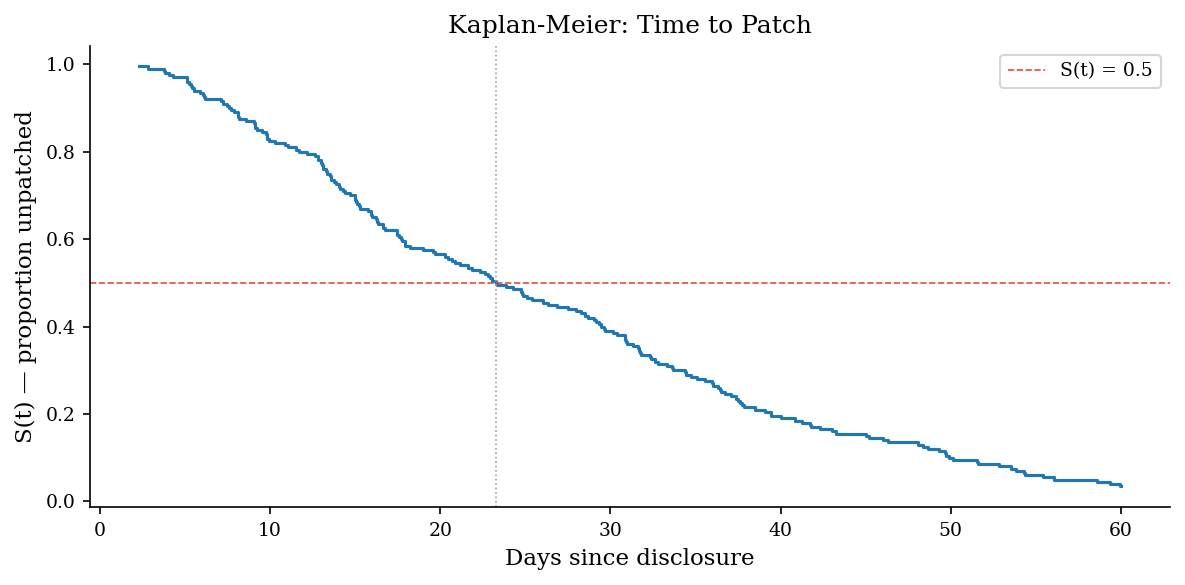

50% of vulnerabilities are patched within 23 days.


In [3]:
km_t, km_s = km_estimator(times, events)

fig, ax = plt.subplots(figsize=(8, 4))
plot_km(km_t, km_s, ax=ax)
ax.axhline(0.5, color=ACCENT, linestyle="--", linewidth=0.8, label="S(t) = 0.5")

median_idx = np.searchsorted(-np.array(km_s), -0.5)
median_time = km_t[median_idx]
ax.axvline(median_time, color=LIGHT_GRAY, linestyle=":", linewidth=0.8)
ax.set_xlabel("Days since disclosure")
ax.set_ylabel("S(t) — proportion unpatched")
ax.set_title("Kaplan-Meier: Time to Patch")
ax.legend()
plt.tight_layout()
plt.show()

print(f"50% of vulnerabilities are patched within {median_time:.0f} days.")

## 4 — Comparing Two Groups

Risk-based patching prioritises critical vulnerabilities over medium ones.
If the policy works, the two groups should have visibly different survival
curves. Here we simulate "critical" (faster patching, k=2.0, λ=14) and
"medium" (slower, k=1.2, λ=45) populations.

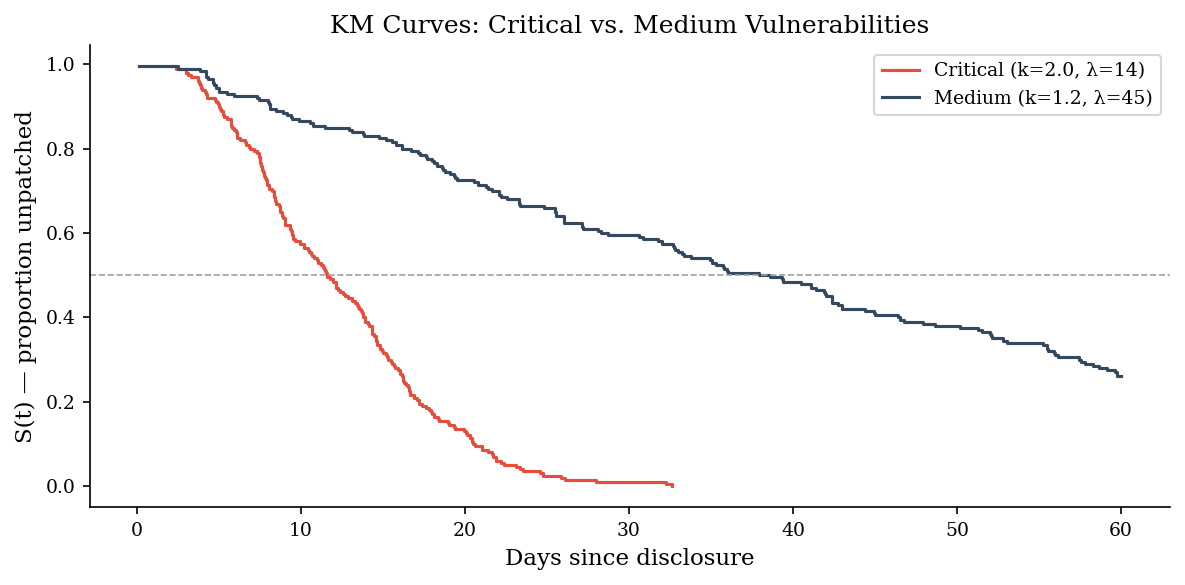

In [4]:
rng_crit = make_rng(42)
rng_med = make_rng(99)

t_crit, e_crit = survival_times("weibull", 200, rng=rng_crit, k=2.0, lam=14, censor_at=60)
t_med, e_med = survival_times("weibull", 200, rng=rng_med, k=1.2, lam=45, censor_at=60)

km_t_c, km_s_c = km_estimator(t_crit, e_crit)
km_t_m, km_s_m = km_estimator(t_med, e_med)

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(km_t_c, km_s_c, where="post", color=ACCENT, label="Critical (k=2.0, λ=14)")
ax.step(km_t_m, km_s_m, where="post", color=DARK_BG, label="Medium (k=1.2, λ=45)")
ax.axhline(0.5, color=LIGHT_GRAY, linestyle="--", linewidth=0.8)
ax.set_xlabel("Days since disclosure")
ax.set_ylabel("S(t) — proportion unpatched")
ax.set_title("KM Curves: Critical vs. Medium Vulnerabilities")
ax.legend()
plt.tight_layout()
plt.show()

## 5 — Cumulative Hazard

The Nelson-Aalen estimator gives the cumulative hazard H(t). The hazard rate
is the instantaneous risk of the event at time t, given survival to t. An
increasing slope means "the longer you wait, the worse it gets" — which is
typical for critical vulnerabilities where exploits mature over time.

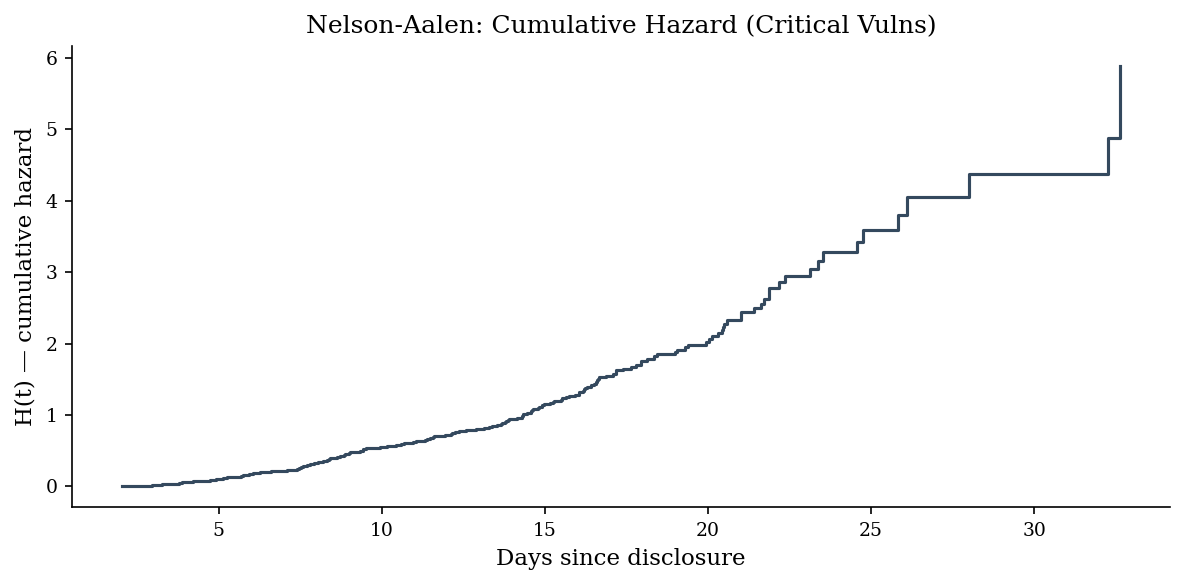

In [5]:
na_t, na_h = nelson_aalen(t_crit, e_crit)

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(na_t, na_h, where="post", color=DARK_BG)
ax.set_xlabel("Days since disclosure")
ax.set_ylabel("H(t) — cumulative hazard")
ax.set_title("Nelson-Aalen: Cumulative Hazard (Critical Vulns)")
plt.tight_layout()
plt.show()

## Pitfalls

- **Censoring is information, not missing data.** Dropping censored observations
  biases survival estimates upward — you are throwing away evidence that the event
  *hadn't happened yet*, which makes everything look faster than it is.

- **Median survival time is not the mean.** Means are dragged by the right tail;
  the median is the time at which S(t) crosses 0.5. For right-skewed
  time-to-event data, the median is almost always the more useful summary.

- **"Days since disclosure" is not "days of exposure."** Clock-start matters for
  time-to-patch metrics. A vulnerability disclosed publicly on day 0 may have
  been silently exploited for months. Survival analysis answers the question you
  ask it — make sure the clock measures what you actually care about.